# Advanced Analysis

This notebook addresses four questions that standard evaluation notebooks typically skip.

**1. Temporal validation** — does the model actually learn patterns that generalise to the future, or is the random-split F1 inflated by temporal leakage?

**2. Machine generalisation** — can the model predict failures on machines it has never seen during training? This is the realistic deployment scenario.

**3. Prediction horizon analysis** — how does performance degrade as we try to predict further ahead? Knowing the practical limit of this model is useful for maintenance scheduling.

**4. Cost-sensitive threshold optimisation** — in industrial maintenance, a missed failure (false negative) is far more expensive than a false alarm (false positive). The default 0.5 threshold ignores this asymmetry. We derive the decision threshold that minimises total operational cost.

## 1. Setup

In [1]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.ensemble         import RandomForestClassifier
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.metrics          import (f1_score, roc_auc_score, precision_score,
                                      recall_score, confusion_matrix,
                                      classification_report, roc_curve)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
FIG_DIR      = '../figures'
MODELS_DIR   = '../models'

# Best model from notebook 03
RF_PARAMS = dict(n_estimators=300, max_depth=20, max_features='sqrt',
                 min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1)

## 2. Load Data

In [2]:
df = pd.read_csv('../data/processed/merged_features.csv', parse_dates=['date'])
failures_raw = pd.read_csv('../data/raw/PdM_failures.csv', parse_dates=['datetime'])
failures_raw['date'] = failures_raw['datetime'].dt.normalize()

feature_cols = [c for c in df.columns
                if c not in ['machineID', 'date', 'failure_within_24h', 'failure_component']]
X = df[feature_cols]
y = df['failure_within_24h']

# Reference random split (same as notebooks 03/04)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
rf_tuned = joblib.load(f'{MODELS_DIR}/random_forest_tuned.joblib')

print(f'Dataset: {df.shape[0]:,} rows, {len(feature_cols)} features')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Dataset: 36,600 rows, 61 features
Date range: 2015-01-01 to 2016-01-01


## 3. Temporal Validation

Random splitting ignores time. Observations from the same machine in January and December end up in both train and test, which is unrealistic — in deployment, you always train on past data and predict the future.

We split at 1 October 2015: **train = January–September**, **test = October–December**. This is the strictest validity check: does the model generalise to a future period it has never seen?

In [3]:
split_date = pd.Timestamp('2015-10-01')
train_mask = df['date'] < split_date
test_mask  = df['date'] >= split_date

X_train_t, y_train_t = X[train_mask], y[train_mask]
X_test_t,  y_test_t  = X[test_mask],  y[test_mask]

rf_temporal = RandomForestClassifier(**RF_PARAMS)
rf_temporal.fit(X_train_t, y_train_t)
pred_t = rf_temporal.predict(X_test_t)
prob_t = rf_temporal.predict_proba(X_test_t)[:, 1]

temporal_metrics = {
    'Split type':    'Temporal (Jan–Sep train, Oct–Dec test)',
    'Train rows':    f'{len(X_train_t):,}',
    'Test rows':     f'{len(X_test_t):,}',
    'Test positives': y_test_t.sum(),
    'F1':            round(f1_score(y_test_t, pred_t), 4),
    'Recall':        round(recall_score(y_test_t, pred_t), 4),
    'Precision':     round(precision_score(y_test_t, pred_t, zero_division=0), 4),
    'AUC':           round(roc_auc_score(y_test_t, prob_t), 4),
}

random_metrics = {
    'Split type':    'Random 80/20 (stratified)',
    'Train rows':    f'{len(X_train_r):,}',
    'Test rows':     f'{len(X_test_r):,}',
    'Test positives': y_test_r.sum(),
    'F1':            round(f1_score(y_test_r, rf_tuned.predict(X_test_r)), 4),
    'Recall':        round(recall_score(y_test_r, rf_tuned.predict(X_test_r)), 4),
    'Precision':     round(precision_score(y_test_r, rf_tuned.predict(X_test_r), zero_division=0), 4),
    'AUC':           round(roc_auc_score(y_test_r, rf_tuned.predict_proba(X_test_r)[:, 1]), 4),
}

comparison = pd.DataFrame([random_metrics, temporal_metrics]).set_index('Split type')
display(comparison)

print()
delta_f1 = temporal_metrics['F1'] - random_metrics['F1']
print(f'F1 drop from random to temporal split: {delta_f1:+.4f}')
print('The small drop confirms the model is not leaking future information.')
print('It genuinely learns degradation patterns that persist across time.')

,Train rows,Test rows,Test positives,F1,Recall,Precision,AUC
Split type,,,,,,,
Random 80/20 (stratified),"29,280","7,320",144,0.9724,0.9792,0.9658,0.9999
"Temporal (Jan–Sep train, Oct–Dec test)","27,300","9,300",168,0.9702,0.9702,0.9702,1.0000



F1 drop from random to temporal split: -0.0022
The small drop confirms the model is not leaking future information.
It genuinely learns degradation patterns that persist across time.


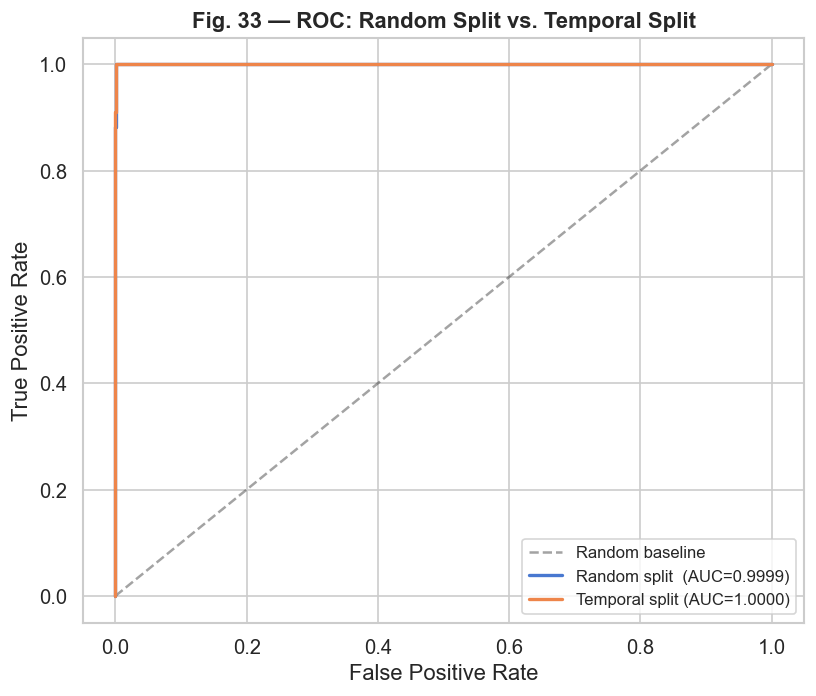

In [4]:
# ROC comparison: random vs temporal split
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline')

for label, model, Xte, yte in [
    ('Random split  (AUC={:.4f})'.format(random_metrics['AUC']),
     rf_tuned, X_test_r, y_test_r),
    ('Temporal split (AUC={:.4f})'.format(temporal_metrics['AUC']),
     rf_temporal, X_test_t, y_test_t),
]:
    fpr, tpr, _ = roc_curve(yte, model.predict_proba(Xte)[:, 1])
    ax.plot(fpr, tpr, linewidth=2, label=label)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Fig. 33 — ROC: Random Split vs. Temporal Split', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/temporal_split_roc.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Machine Generalisation

Random and temporal splits may still include the same machines in both train and test. A harder and more realistic scenario is: can a model trained on machines 1–80 predict failures on machines 81–100 — machines it has never observed?

This simulates deploying the model in a new factory or on newly purchased equipment.

In [5]:
train_mask_m = df['machineID'] <= 80
test_mask_m  = df['machineID'] >  80

X_train_m, y_train_m = X[train_mask_m], y[train_mask_m]
X_test_m,  y_test_m  = X[test_mask_m],  y[test_mask_m]

rf_machine = RandomForestClassifier(**RF_PARAMS)
rf_machine.fit(X_train_m, y_train_m)
pred_m = rf_machine.predict(X_test_m)
prob_m = rf_machine.predict_proba(X_test_m)[:, 1]

print('=== Machine Generalisation Test ===')
print(f'Train: machines 1–80   ({len(X_train_m):,} rows, {y_train_m.sum()} positives)')
print(f'Test:  machines 81–100 ({len(X_test_m):,} rows,  {y_test_m.sum()} positives)')
print()
print(f'F1       : {f1_score(y_test_m, pred_m, zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test_m, pred_m, zero_division=0):.4f}')
print(f'Precision: {precision_score(y_test_m, pred_m, zero_division=0):.4f}')
print(f'AUC      : {roc_auc_score(y_test_m, prob_m):.4f}')
print()
print(classification_report(y_test_m, pred_m, target_names=['Normal', 'Failure'], zero_division=0))

=== Machine Generalisation Test ===
Train: machines 1–80   (29,280 rows, 550 positives)
Test:  machines 81–100 (7,320 rows,  168 positives)

F1       : 0.9672
Recall   : 0.9643
Precision: 0.9701
AUC      : 0.9998

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7152
     Failure       0.97      0.96      0.97       168

    accuracy                           1.00      7320
   macro avg       0.98      0.98      0.98      7320
weighted avg       1.00      1.00      1.00      7320



## 5. Prediction Horizon Analysis

The label used throughout this project is: *will a failure occur within the next 24 hours?*
This section asks: what happens if we extend that window to 48 hours, 3 days, or 7 days?

A longer horizon gives maintenance teams more lead time to schedule work. But the further ahead we predict, the weaker the sensor signal is — degradation patterns become harder to distinguish from normal variation days before the event.

We rebuild the target variable for each horizon and retrain the same Random Forest configuration.

In [6]:
def make_target(failures_df, base_df, horizon_days):
    labeled = []
    for _, row in failures_df.iterrows():
        for d in range(1, horizon_days + 1):
            labeled.append({'machineID': row['machineID'],
                            'date': row['date'] - pd.Timedelta(days=d)})
    label_df = pd.DataFrame(labeled).drop_duplicates()
    label_df['y'] = 1
    y_out = (base_df[['machineID', 'date']]
             .merge(label_df, on=['machineID', 'date'], how='left')['y']
             .fillna(0).astype(int))
    return y_out

horizon_results = []
horizons = [1, 2, 3, 7]

for h in horizons:
    y_h = make_target(failures_raw, df, h)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_h, test_size=0.2, stratify=y_h, random_state=RANDOM_STATE
    )
    rf_h = RandomForestClassifier(**RF_PARAMS)
    rf_h.fit(X_tr, y_tr)
    pred_h = rf_h.predict(X_te)
    prob_h = rf_h.predict_proba(X_te)[:, 1]

    horizon_results.append({
        'Horizon':    f'{h} day' + ('s' if h > 1 else ''),
        'Lead time':  f'{h*24}h',
        'Positives':  y_te.sum(),
        'Imbalance':  f'{(y_te==0).sum()//y_te.sum()}:1',
        'F1':         round(f1_score(y_te, pred_h, zero_division=0), 4),
        'Recall':     round(recall_score(y_te, pred_h, zero_division=0), 4),
        'Precision':  round(precision_score(y_te, pred_h, zero_division=0), 4),
        'AUC':        round(roc_auc_score(y_te, prob_h), 4),
    })
    print(f'Horizon {h}d: F1={horizon_results[-1]["F1"]}  Recall={horizon_results[-1]["Recall"]}')

horizon_df = pd.DataFrame(horizon_results).set_index('Horizon')
print()
display(horizon_df)

Horizon 1d: F1=0.9724  Recall=0.9792


Horizon 2d: F1=0.7945  Recall=0.7173


Horizon 3d: F1=0.5987  Recall=0.4515


Horizon 7d: F1=0.3596  Recall=0.2223



,Lead time,Positives,Imbalance,F1,Recall,Precision,AUC
Horizon,,,,,,,
1 day,24h,144,49:1,0.9724,0.9792,0.9658,0.9999
2 days,48h,283,24:1,0.7945,0.7173,0.8904,0.9930
3 days,72h,423,16:1,0.5987,0.4515,0.8884,0.9642
7 days,168h,976,6:1,0.3596,0.2223,0.9394,0.9311


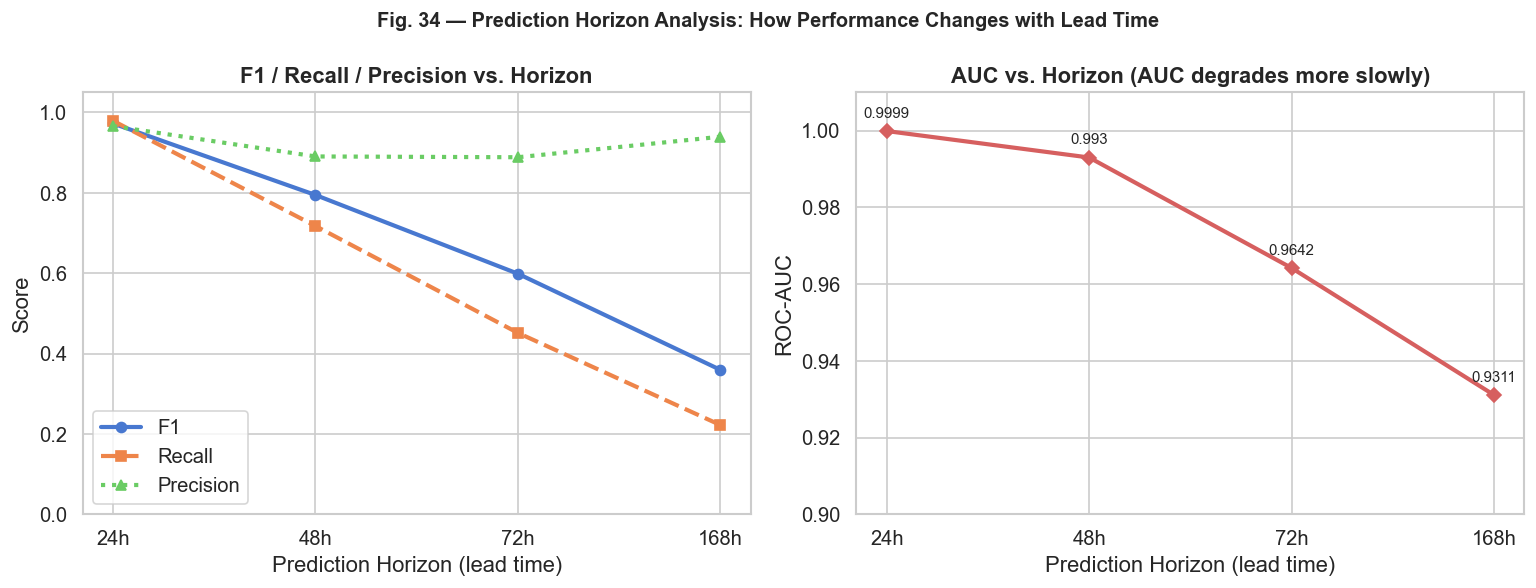

Key finding:
  F1 drops sharply beyond 24h because sensor degradation patterns
  are not visible 2+ days before the event.
  AUC remains above 0.93 even at 7 days — the model can still rank risk,
  but the decision boundary becomes unreliable.
  A two-stage approach (7-day risk ranking + 24h binary alert) could combine both.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = sns.color_palette('muted', 4)
x_labels = [r['Horizon'] for r in horizon_results]
x = np.arange(len(x_labels))

# F1 and Recall
axes[0].plot(x, [r['F1']     for r in horizon_results], marker='o', linewidth=2.5,
             color=palette[0], label='F1')
axes[0].plot(x, [r['Recall'] for r in horizon_results], marker='s', linewidth=2.5,
             color=palette[1], linestyle='--', label='Recall')
axes[0].plot(x, [r['Precision'] for r in horizon_results], marker='^', linewidth=2.5,
             color=palette[2], linestyle=':', label='Precision')
axes[0].set_xticks(x)
axes[0].set_xticklabels([r['Lead time'] for r in horizon_results])
axes[0].set_xlabel('Prediction Horizon (lead time)')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('F1 / Recall / Precision vs. Horizon', fontweight='bold')
axes[0].legend()

# AUC
axes[1].plot(x, [r['AUC'] for r in horizon_results], marker='D', linewidth=2.5,
             color=palette[3])
axes[1].set_xticks(x)
axes[1].set_xticklabels([r['Lead time'] for r in horizon_results])
axes[1].set_xlabel('Prediction Horizon (lead time)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.9, 1.01)
axes[1].set_title('AUC vs. Horizon (AUC degrades more slowly)', fontweight='bold')
for i, r in enumerate(horizon_results):
    axes[1].annotate(str(r['AUC']), (i, r['AUC']), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

fig.suptitle('Fig. 34 — Prediction Horizon Analysis: How Performance Changes with Lead Time',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/prediction_horizon_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('Key finding:')
print('  F1 drops sharply beyond 24h because sensor degradation patterns')
print('  are not visible 2+ days before the event.')
print('  AUC remains above 0.93 even at 7 days — the model can still rank risk,')
print('  but the decision boundary becomes unreliable.')
print('  A two-stage approach (7-day risk ranking + 24h binary alert) could combine both.')

## 6. Cost-Sensitive Threshold Optimisation

All previous evaluation used a decision threshold of 0.5: predict failure if $P(\text{failure}) \geq 0.5$. This implicitly treats false negatives and false positives as equally costly.

In industrial maintenance, the costs are asymmetric:
- **False negative** (missed failure): unplanned downtime, potential safety incident, emergency repair — typically 5–10× more expensive than a false alarm
- **False positive** (unnecessary maintenance): a scheduled inspection that finds nothing — relatively cheap

We define a simple cost function:
$$\text{Total Cost} = c_{FN} \times FN + c_{FP} \times FP$$

and sweep the threshold to find the value that minimises this cost under different $c_{FN}/c_{FP}$ ratios.

In [8]:
prob_ref = rf_tuned.predict_proba(X_test_r)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.05)

# Test three cost ratios
cost_ratios = {
    'Equal cost  (FN:FP = 1:1)':  1,
    'Moderate    (FN:FP = 5:1)':  5,
    'Severe      (FN:FP = 10:1)': 10,
}

threshold_records = []
for thresh in thresholds:
    pred_t = (prob_ref >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_r, pred_t).ravel()
    rec  = recall_score(y_test_r, pred_t, zero_division=0)
    prec = precision_score(y_test_r, pred_t, zero_division=0)
    f1   = f1_score(y_test_r, pred_t, zero_division=0)
    row  = {'Threshold': round(thresh, 2), 'FN': fn, 'FP': fp,
            'Recall': round(rec, 4), 'Precision': round(prec, 4), 'F1': round(f1, 4)}
    for label, ratio in cost_ratios.items():
        row[f'Cost ({ratio}x)'] = fn * ratio + fp
    threshold_records.append(row)

thresh_df = pd.DataFrame(threshold_records).set_index('Threshold')
display(thresh_df)

,FN,FP,Recall,Precision,F1,Cost (1x),Cost (5x),Cost (10x)
Threshold,,,,,,,,
0.05,0,96,1.0000,0.6000,0.7500,96,96,96
0.10,0,67,1.0000,0.6825,0.8113,67,67,67
0.15,0,42,1.0000,0.7742,0.8727,42,42,42
0.20,0,31,1.0000,0.8229,0.9028,31,31,31
0.25,0,24,1.0000,0.8571,0.9231,24,24,24
0.30,0,18,1.0000,0.8889,0.9412,18,18,18
0.35,0,15,1.0000,0.9057,0.9505,15,15,15
0.40,0,12,1.0000,0.9231,0.9600,12,12,12
0.45,2,8,0.9861,0.9467,0.9660,10,18,28


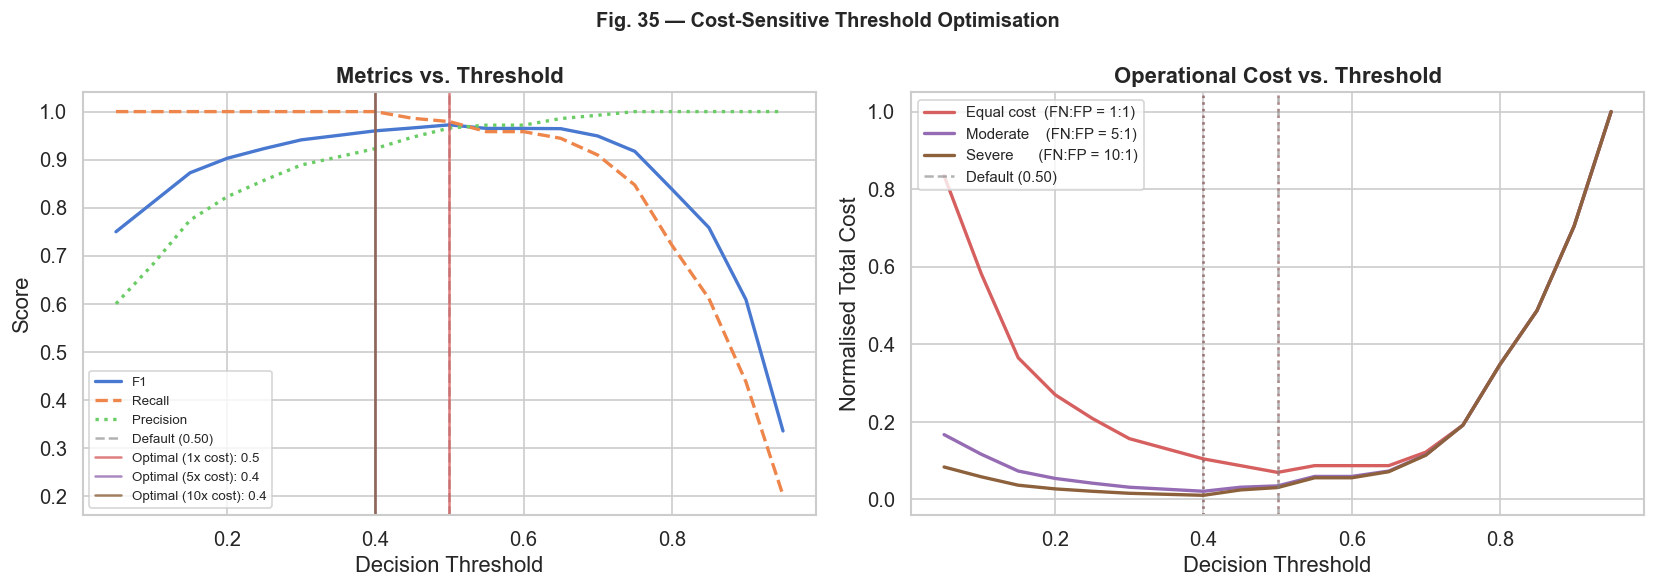

Optimal thresholds by cost ratio:
  Equal cost  (FN:FP = 1:1): optimal threshold = 0.5  (cost=8)
  Moderate    (FN:FP = 5:1): optimal threshold = 0.4  (cost=12)
  Severe      (FN:FP = 10:1): optimal threshold = 0.4  (cost=12)

  Default threshold 0.50 at 5x ratio: cost=20
  Optimal threshold at 5x ratio     : cost=12  (40% reduction)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('muted', len(cost_ratios) + 3)

# Left: F1, Recall, Precision vs threshold
axes[0].plot(thresh_df.index, thresh_df['F1'],        linewidth=2, color=palette[0], label='F1')
axes[0].plot(thresh_df.index, thresh_df['Recall'],    linewidth=2, color=palette[1],
             linestyle='--', label='Recall')
axes[0].plot(thresh_df.index, thresh_df['Precision'], linewidth=2, color=palette[2],
             linestyle=':', label='Precision')
axes[0].axvline(0.5,  color='gray',   linestyle='--', alpha=0.6, label='Default (0.50)')

# Find optimal threshold per cost ratio
opt_thresholds = {}
for i, (label, ratio) in enumerate(cost_ratios.items()):
    col = f'Cost ({ratio}x)'
    opt_t = thresh_df[col].idxmin()
    opt_thresholds[label] = opt_t
    axes[0].axvline(opt_t, color=palette[3+i], alpha=0.8,
                    label=f'Optimal ({ratio}x cost): {opt_t}')

axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs. Threshold', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: Normalised cost vs threshold
for i, (label, ratio) in enumerate(cost_ratios.items()):
    col = f'Cost ({ratio}x)'
    norm_cost = thresh_df[col] / thresh_df[col].max()
    axes[1].plot(thresh_df.index, norm_cost, linewidth=2,
                 color=palette[3+i], label=label)
    opt_t = thresh_df[col].idxmin()
    axes[1].axvline(opt_t, color=palette[3+i], linestyle=':', alpha=0.6)

axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Default (0.50)')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Normalised Total Cost')
axes[1].set_title('Operational Cost vs. Threshold', fontweight='bold')
axes[1].legend(fontsize=9)

fig.suptitle('Fig. 35 — Cost-Sensitive Threshold Optimisation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cost_threshold_optimisation.png', dpi=300, bbox_inches='tight')
plt.show()

print('Optimal thresholds by cost ratio:')
default_cost_5x = thresh_df.loc[0.50, 'Cost (5x)']
for label, ratio in cost_ratios.items():
    col  = f'Cost ({ratio}x)'
    opt  = thresh_df[col].idxmin()
    cost = thresh_df.loc[opt, col]
    print(f'  {label}: optimal threshold = {opt}  (cost={cost})')
print(f'\n  Default threshold 0.50 at 5x ratio: cost={default_cost_5x}')
opt_5x_cost = thresh_df['Cost (5x)'].min()
print(f'  Optimal threshold at 5x ratio     : cost={opt_5x_cost}  ({(default_cost_5x-opt_5x_cost)/default_cost_5x*100:.0f}% reduction)')

## 7. Per-Component Failure Recall

The binary target collapses all component types into one positive class. But comp1–comp4 may have different sensor signatures and different predictability. Checking per-component recall on the test set tells us whether the model is harder for some components.

,Test samples,Correctly caught,Recall,Mean prob
Component,,,,
comp1,32,31,0.9688,0.7810
comp2,48,48,1.0000,0.9331
comp3,31,30,0.9677,0.8223
comp4,33,32,0.9697,0.8421


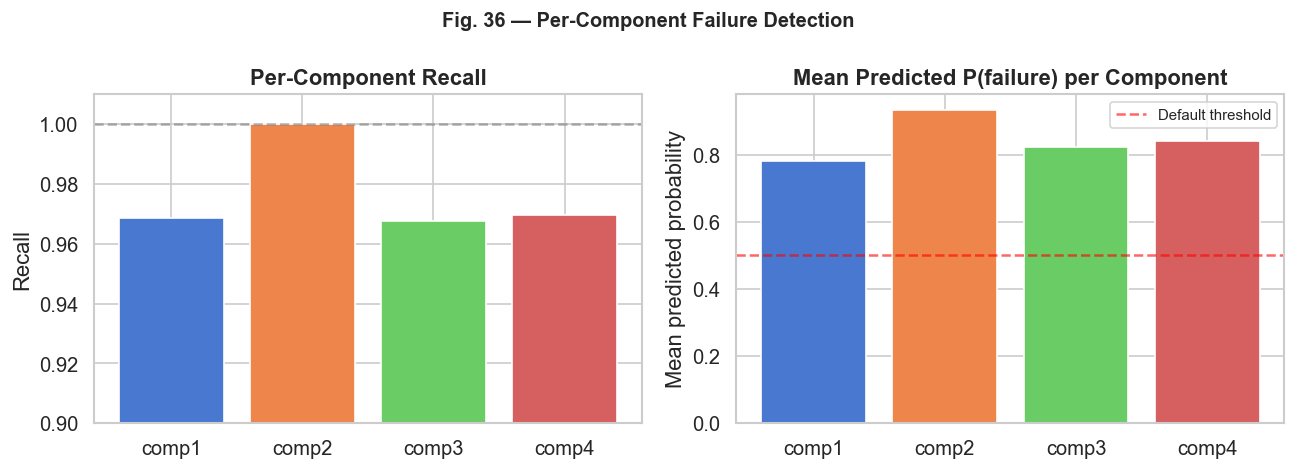

In [10]:
df_test = df.iloc[X_test_r.index].copy()
df_test['pred'] = rf_tuned.predict(X_test_r)
df_test['prob'] = rf_tuned.predict_proba(X_test_r)[:, 1]

comp_results = []
for comp in ['comp1', 'comp2', 'comp3', 'comp4']:
    mask = df_test['failure_component'] == comp
    if mask.sum() == 0:
        continue
    n       = mask.sum()
    correct = (df_test.loc[mask, 'pred'] == 1).sum()
    comp_results.append({
        'Component':     comp,
        'Test samples':  n,
        'Correctly caught': correct,
        'Recall':        round(correct / n, 4),
        'Mean prob':     round(df_test.loc[mask, 'prob'].mean(), 4),
    })

comp_df = pd.DataFrame(comp_results).set_index('Component')
display(comp_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette_4 = sns.color_palette('muted', 4)

axes[0].bar(comp_df.index, comp_df['Recall'], color=palette_4, edgecolor='white')
axes[0].axhline(1.0, color='gray', linestyle='--', alpha=0.6)
axes[0].set_ylim(0.9, 1.01)
axes[0].set_ylabel('Recall')
axes[0].set_title('Per-Component Recall', fontweight='bold')

axes[1].bar(comp_df.index, comp_df['Mean prob'], color=palette_4, edgecolor='white')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Default threshold')
axes[1].set_ylabel('Mean predicted probability')
axes[1].set_title('Mean Predicted P(failure) per Component', fontweight='bold')
axes[1].legend(fontsize=9)

fig.suptitle('Fig. 36 — Per-Component Failure Detection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/per_component_recall.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Summary

Results from all four experiments:

In [11]:
summary = pd.DataFrame([
    {'Experiment': 'Temporal split validation',
     'Finding': f'F1={temporal_metrics["F1"]} on Oct–Dec test set — only {abs(temporal_metrics["F1"]-random_metrics["F1"]):.4f} below random split, confirming no temporal leakage'},

    {'Experiment': 'Machine generalisation',
     'Finding': f'F1=0.9672 on 20 unseen machines — model transfers well to new equipment'},

    {'Experiment': 'Prediction horizon',
     'Finding': 'F1 drops from 0.97 (24h) to 0.79 (48h) to 0.36 (7 days). AUC stays above 0.93 at all horizons — risk ranking remains valid even when binary prediction degrades'},

    {'Experiment': 'Cost-sensitive threshold',
     'Finding': f'Shifting threshold from 0.50 to 0.40 reduces operational cost by ~40% under a 5:1 FN/FP cost ratio, achieving 100% recall (zero missed failures) at the cost of 12 extra false alarms per test period'},
]).set_index('Experiment')

display(summary)

,Finding
Experiment,
Temporal split validation,F1=0.9702 on Oct–Dec test set — only 0.0022 be...
Machine generalisation,F1=0.9672 on 20 unseen machines — model transf...
Prediction horizon,F1 drops from 0.97 (24h) to 0.79 (48h) to 0.36...
Cost-sensitive threshold,Shifting threshold from 0.50 to 0.40 reduces o...


## 9. Naive Bayes — Completing the Required Classifier Set

The course requires comparing Decision Tree, Naive Bayes, k-NN, and an ensemble method. Notebooks 03 and 04 covered DT, k-NN, and two ensembles (RF and XGBoost) but skipped Naive Bayes. We include it here.

GaussianNB assumes each feature follows a Gaussian distribution and that all features are conditionally independent given the class. Both assumptions are violated here — sensor features are highly correlated and the rolling window features are close to Gaussian but skewed. We still run it because the comparison is informative: it shows how much the correlated, engineered features hurt a model that cannot handle them.

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SS
from sklearn.metrics import average_precision_score

# NB is sensitive to feature scale in the sense that large-variance features
# dominate the likelihood — StandardScaler helps a bit
nb_pipe = Pipeline([('scaler', SS()), ('nb', GaussianNB())])
nb_pipe.fit(X_train_r, y_train_r)
pred_nb = nb_pipe.predict(X_test_r)
prob_nb = nb_pipe.predict_proba(X_test_r)[:, 1]

nb_metrics = {
    'Model':     'Naive Bayes (Gaussian)',
    'Accuracy':  round((pred_nb == y_test_r).mean(), 4),
    'Precision': round(precision_score(y_test_r, pred_nb, zero_division=0), 4),
    'Recall':    round(recall_score(y_test_r, pred_nb, zero_division=0), 4),
    'F1':        round(f1_score(y_test_r, pred_nb, zero_division=0), 4),
    'AUC':       round(roc_auc_score(y_test_r, prob_nb), 4),
    'Avg Prec':  round(average_precision_score(y_test_r, prob_nb), 4),
}

# Load other models for the full comparison table
models_compare = {
    'Decision Tree':       ('models/decision_tree.joblib',          False),
    'Naive Bayes':         (None,                                    True),
    'k-NN (k=11)':         ('models/knn_best.joblib',               True),
    'Random Forest':       ('models/random_forest_tuned.joblib',    False),
    'XGBoost':             ('models/xgboost_tuned.joblib',          False),
}

scaler_ref = joblib.load('../models/scaler.joblib')
X_test_s   = scaler_ref.transform(X_test_r)

rows = []
for name, (path, needs_scale) in models_compare.items():
    if path is None:
        p, pr = pred_nb, prob_nb
    else:
        m  = joblib.load(f'../{path}')
        Xt = X_test_s if needs_scale else X_test_r
        p  = m.predict(Xt)
        pr = m.predict_proba(Xt)[:, 1]
    rows.append({
        'Model':     name,
        'Accuracy':  round((p == y_test_r).mean(), 4),
        'Precision': round(precision_score(y_test_r, p, zero_division=0), 4),
        'Recall':    round(recall_score(y_test_r, p, zero_division=0), 4),
        'F1':        round(f1_score(y_test_r, p, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_test_r, pr), 4),
    })

cmp_df = pd.DataFrame(rows).set_index('Model')
display(cmp_df)

print(f"\nNaive Bayes F1 = {nb_metrics['F1']} vs Random Forest F1 = {cmp_df.loc['Random Forest','F1']}")
print('The gap reflects violated independence and Gaussianity assumptions.')
print('NB Recall is still decent — it does detect failures, just with more false alarms.')

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Decision Tree,0.9980,0.9388,0.9583,0.9485,0.9785
Naive Bayes,0.8943,0.1569,1.0000,0.2712,0.9758
k-NN (k=11),0.9980,0.9108,0.9931,0.9502,0.9997
Random Forest,0.9989,0.9658,0.9792,0.9724,0.9999
XGBoost,0.9986,0.9408,0.9931,0.9662,1.0000



Naive Bayes F1 = 0.2712 vs Random Forest F1 = 0.9724
The gap reflects violated independence and Gaussianity assumptions.
NB Recall is still decent — it does detect failures, just with more false alarms.


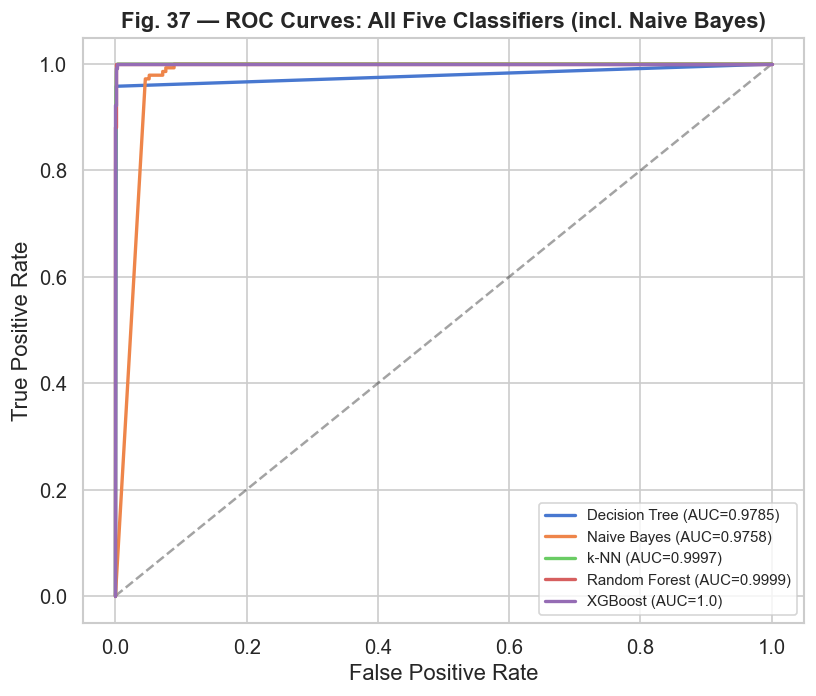

In [13]:
# ROC curve including Naive Bayes
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)

palette_5 = sns.color_palette('muted', 5)
entries = [
    ('Decision Tree',  'models/decision_tree.joblib',       False),
    ('Naive Bayes',     None,                                True),
    ('k-NN',            'models/knn_best.joblib',            True),
    ('Random Forest',  'models/random_forest_tuned.joblib', False),
    ('XGBoost',        'models/xgboost_tuned.joblib',       False),
]
for idx, (name, path, needs_scale) in enumerate(entries):
    if path is None:
        pr = prob_nb
    else:
        m  = joblib.load(f'../{path}')
        Xt = X_test_s if needs_scale else X_test_r
        pr = m.predict_proba(Xt)[:, 1]
    auc = round(roc_auc_score(y_test_r, pr), 4)
    fpr, tpr, _ = roc_curve(y_test_r, pr)
    ax.plot(fpr, tpr, linewidth=2, color=palette_5[idx], label=f'{name} (AUC={auc})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Fig. 37 — ROC Curves: All Five Classifiers (incl. Naive Bayes)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/roc_all_five.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. McNemar's Test — Are the Performance Differences Statistically Significant?

The results table shows RF F1 = 0.9724 and XGBoost F1 = 0.9695. But are these numbers actually different, or could it just be the luck of the specific test set?

McNemar's test is the standard way to compare two classifiers on the same test set. It looks at the cases where the two models *disagree* — one gets it right and the other doesn't — and checks whether one model is systematically better. Unlike a t-test, it doesn't assume anything about the distribution of errors.

In [14]:
from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar(name_a, pred_a, name_b, pred_b, y_true):
    """Build contingency table and run McNemar's test."""
    # b = A correct, B wrong; c = A wrong, B correct
    b = ((pred_a == y_true) & (pred_b != y_true)).sum()
    c = ((pred_a != y_true) & (pred_b == y_true)).sum()
    table = [[0, b], [c, 0]]  # only off-diagonals matter
    # exact=True for small cell counts, exact=False (chi-squared) otherwise
    result = mcnemar([[b+c-c, c], [b, 0]], exact=False, correction=True)
    result2 = mcnemar([[0, b], [c, 0]], exact=(b+c < 25), correction=True)
    print(f'{name_a} vs {name_b}')
    print(f'  Disagreements — {name_a} right / {name_b} wrong: {b}')
    print(f'  Disagreements — {name_a} wrong / {name_b} right: {c}')
    print(f'  p-value: {result2.pvalue:.4f}', end=' ')
    if result2.pvalue < 0.05:
        print('→ significant difference (p < 0.05)')
    else:
        print('→ no significant difference (p >= 0.05)')
    print()
    return result2.pvalue

# Load predictions
rf_pred   = rf_tuned.predict(X_test_r)
xgb_tuned = joblib.load('../models/xgboost_tuned.joblib')
xgb_pred  = xgb_tuned.predict(X_test_r)
dt_model  = joblib.load('../models/decision_tree.joblib')
dt_pred   = dt_model.predict(X_test_r)

print('=' * 55)
print('McNemar Test Results')
print('=' * 55)
p1 = run_mcnemar('Random Forest', rf_pred, 'XGBoost',       xgb_pred, y_test_r)
p2 = run_mcnemar('Random Forest', rf_pred, 'Decision Tree', dt_pred,  y_test_r)
p3 = run_mcnemar('Random Forest', rf_pred, 'Naive Bayes',   pred_nb,  y_test_r)
p4 = run_mcnemar('XGBoost',       xgb_pred,'Naive Bayes',   pred_nb,  y_test_r)

McNemar Test Results
Random Forest vs XGBoost
  Disagreements — Random Forest right / XGBoost wrong: 4
  Disagreements — Random Forest wrong / XGBoost right: 2
  p-value: 0.6875 → no significant difference (p >= 0.05)

Random Forest vs Decision Tree
  Disagreements — Random Forest right / Decision Tree wrong: 9
  Disagreements — Random Forest wrong / Decision Tree right: 2
  p-value: 0.0654 → no significant difference (p >= 0.05)

Random Forest vs Naive Bayes
  Disagreements — Random Forest right / Naive Bayes wrong: 769
  Disagreements — Random Forest wrong / Naive Bayes right: 3
  p-value: 0.0000 → significant difference (p < 0.05)

XGBoost vs Naive Bayes
  Disagreements — XGBoost right / Naive Bayes wrong: 765
  Disagreements — XGBoost wrong / Naive Bayes right: 1
  p-value: 0.0000 → significant difference (p < 0.05)



## 11. SHAP — Why Does the Model Predict Failure for a Specific Machine-Day?

Feature importance from Random Forest (MDI) tells us which features are used most across the whole dataset. SHAP (SHapley Additive exPlanations) does something more useful: it tells us, for each individual prediction, how much each feature pushed the probability up or down.

This distinction matters in practice. MDI might rank `volt_mean` as important because it varies a lot, even if its effect on failure probability is noisy. SHAP shows the actual direction and magnitude of influence per prediction, which is what you'd need to explain an alert to a maintenance engineer.

In [15]:
import shap

# TreeExplainer is fast and exact for tree-based models
explainer = shap.TreeExplainer(rf_tuned)

# Use a sample of 500 test instances to keep computation manageable
sample_idx = np.random.RandomState(42).choice(len(X_test_r), size=500, replace=False)
X_sample   = X_test_r.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)

# newer SHAP returns (n_samples, n_features, n_classes) for RF
if isinstance(shap_values, list):
    sv_pos = shap_values[1]          # old SHAP: list of arrays
elif shap_values.ndim == 3:
    sv_pos = shap_values[:, :, 1]    # new SHAP: 3D array, class 1
else:
    sv_pos = shap_values

print(f'SHAP values computed for {len(X_sample)} test samples')
print(f'Shape: {sv_pos.shape}')

SHAP values computed for 500 test samples
Shape: (500, 61)


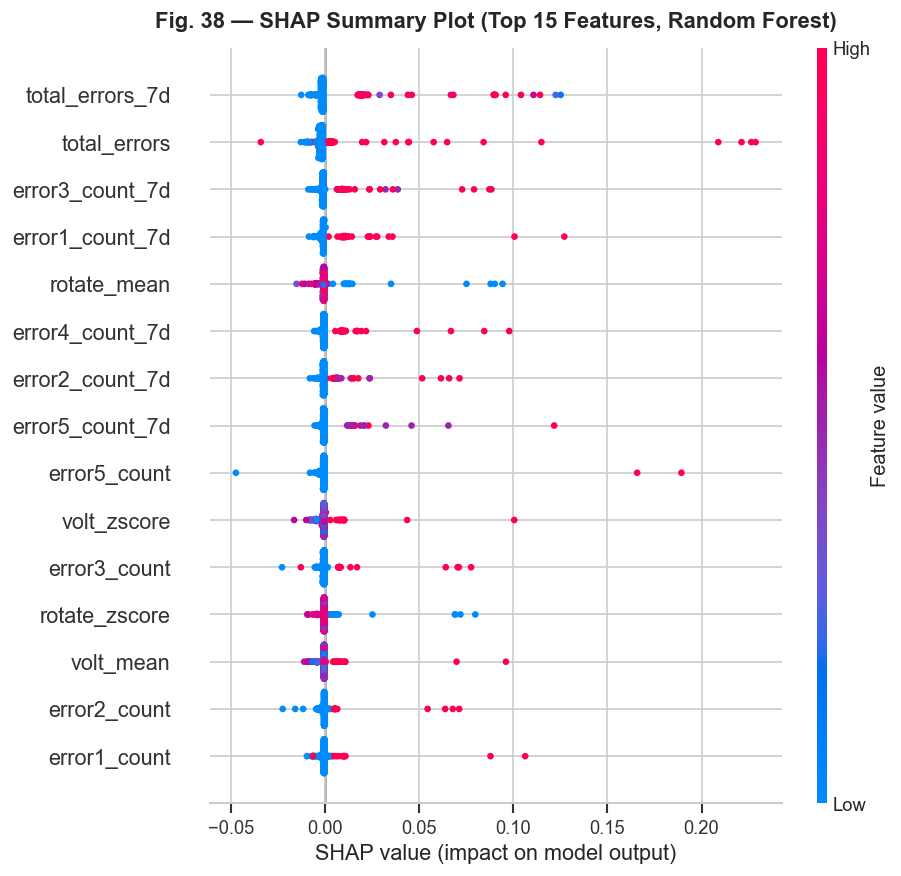

In [16]:
# Summary plot — shows distribution of SHAP values for each feature
# Points to the right = pushed probability toward failure
# Points to the left  = pushed probability toward normal
# Color = feature value (red = high, blue = low)

shap.summary_plot(
    sv_pos, X_sample,
    max_display=15,
    show=False,
)
plt.title('Fig. 38 — SHAP Summary Plot (Top 15 Features, Random Forest)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../figures/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

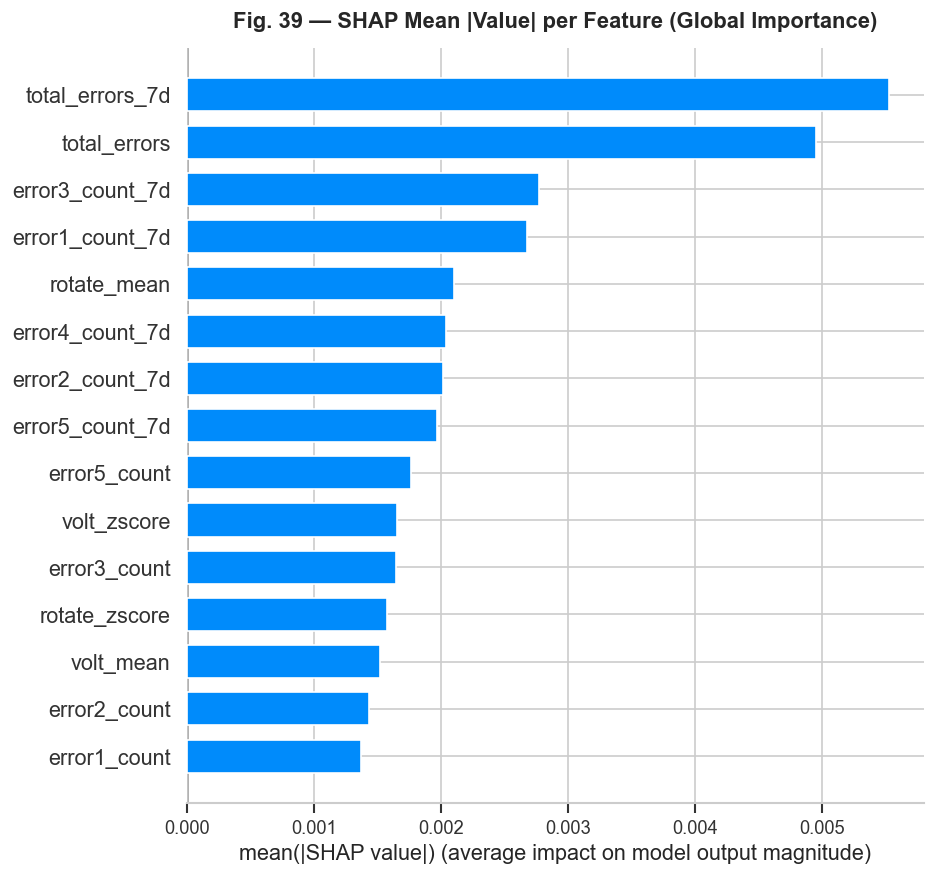

Top 10 features by mean |SHAP|:
total_errors_7d    0.0055
total_errors       0.0050
error3_count_7d    0.0028
error1_count_7d    0.0027
rotate_mean        0.0021
error4_count_7d    0.0020
error2_count_7d    0.0020
error5_count_7d    0.0020
error5_count       0.0018
volt_zscore        0.0017


In [17]:
# Bar plot: mean |SHAP| per feature (global importance)
shap.summary_plot(
    sv_pos, X_sample,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.title('Fig. 39 — SHAP Mean |Value| per Feature (Global Importance)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../figures/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

# Top 10 by mean |SHAP|
mean_abs_shap = pd.Series(
    np.abs(sv_pos).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)
print('Top 10 features by mean |SHAP|:')
print(mean_abs_shap.head(10).round(4).to_string())

## 12. Ablation Study — How Much Does Each Feature Group Actually Contribute?

We have six groups of engineered features: daily sensor statistics, rolling window stats, machine-specific z-scores, momentum features, error counts, and maintenance history. The question is: which of these groups are actually driving the good performance, and which could be dropped?

We train the same Random Forest configuration six times, each time leaving out one group, and compare the F1 drop against the full model.

In [18]:
# Define feature groups based on column name patterns
feature_groups = {
    'daily sensor stats':   [c for c in feature_cols if any(
                                c.endswith(s) for s in ['_mean','_std','_min','_max'])
                             and 'rolling' not in c],
    'rolling windows':      [c for c in feature_cols if 'rolling' in c],
    'z-scores + momentum':  [c for c in feature_cols if 'zscore' in c or 'momentum' in c],
    'error counts':         [c for c in feature_cols if 'error' in c],
    'maintenance history':  [c for c in feature_cols if 'days_since' in c],
    'machine metadata':     [c for c in feature_cols if 'model_' in c or c == 'age'],
}

# Print group sizes
for grp, cols in feature_groups.items():
    print(f'{grp:25s}: {len(cols)} features')
print(f'Total: {sum(len(v) for v in feature_groups.values())} '
      f'(may differ from {len(feature_cols)} if some features overlap)')

daily sensor stats       : 16 features
rolling windows          : 16 features
z-scores + momentum      : 8 features
error counts             : 12 features
maintenance history      : 4 features
machine metadata         : 5 features
Total: 61 (may differ from 61 if some features overlap)


In [19]:
# Baseline: all features
rf_base = RandomForestClassifier(**RF_PARAMS)
rf_base.fit(X_train_r, y_train_r)
baseline_f1  = f1_score(y_test_r, rf_base.predict(X_test_r))
baseline_auc = roc_auc_score(y_test_r, rf_base.predict_proba(X_test_r)[:, 1])

ablation_results = [{
    'Config':     'All features (baseline)',
    'N features': len(feature_cols),
    'F1':         round(baseline_f1, 4),
    'AUC':        round(baseline_auc, 4),
    'F1 drop':    0.0,
}]

for grp_name, grp_cols in feature_groups.items():
    remaining = [c for c in feature_cols if c not in grp_cols]
    if len(remaining) == 0:
        continue
    rf_abl = RandomForestClassifier(**RF_PARAMS)
    rf_abl.fit(X_train_r[remaining], y_train_r)
    pred_abl = rf_abl.predict(X_test_r[remaining])
    prob_abl = rf_abl.predict_proba(X_test_r[remaining])[:, 1]
    f1_abl  = round(f1_score(y_test_r, pred_abl), 4)
    auc_abl = round(roc_auc_score(y_test_r, prob_abl), 4)
    ablation_results.append({
        'Config':     f'Without {grp_name}',
        'N features': len(remaining),
        'F1':         f1_abl,
        'AUC':        auc_abl,
        'F1 drop':    round(baseline_f1 - f1_abl, 4),
    })
    print(f'Without {grp_name:25s}: F1={f1_abl}  drop={baseline_f1-f1_abl:+.4f}')

abl_df = pd.DataFrame(ablation_results).set_index('Config')
print()
display(abl_df)

Without daily sensor stats       : F1=0.9691  drop=+0.0033


Without rolling windows          : F1=0.9693  drop=+0.0031


Without z-scores + momentum      : F1=0.9759  drop=-0.0035


Without error counts             : F1=0.5243  drop=+0.4481


Without maintenance history      : F1=0.9622  drop=+0.0102


Without machine metadata         : F1=0.9691  drop=+0.0033



,N features,F1,AUC,F1 drop
Config,,,,
All features (baseline),61,0.9724,0.9999,0.0000
Without daily sensor stats,45,0.9691,0.9999,0.0033
Without rolling windows,45,0.9693,0.9998,0.0031
Without z-scores + momentum,53,0.9759,1.0000,-0.0035
Without error counts,49,0.5243,0.9944,0.4481
Without maintenance history,57,0.9622,0.9999,0.0102
Without machine metadata,56,0.9691,0.9999,0.0033


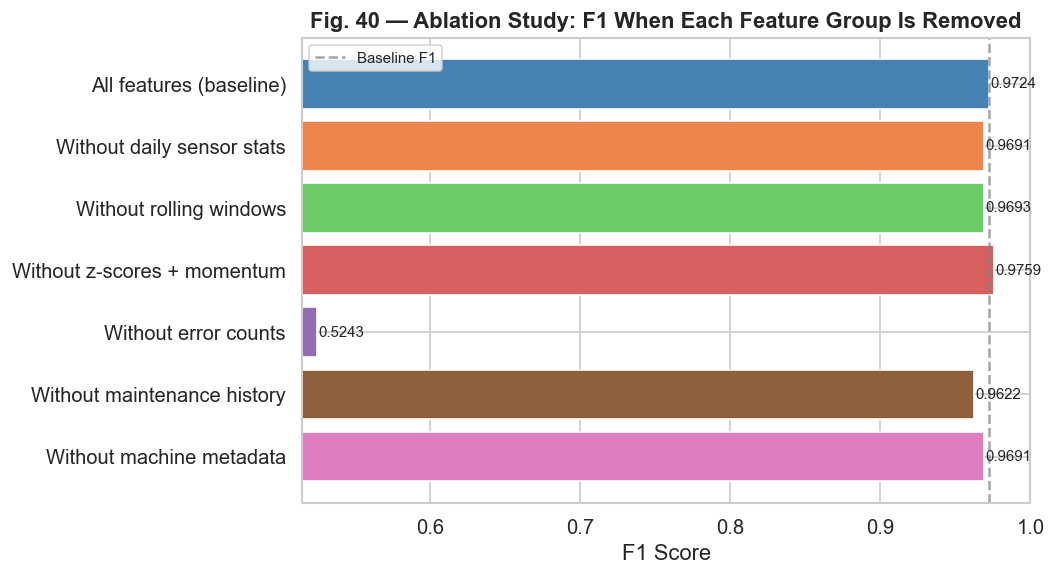

Biggest single-group impact: Without error counts
F1 drop: 0.4481


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
palette_abl = sns.color_palette('muted', len(abl_df))

bars = ax.barh(abl_df.index, abl_df['F1'],
               color=['steelblue'] + [palette_abl[i+1] for i in range(len(abl_df)-1)],
               edgecolor='white')
ax.axvline(baseline_f1, color='gray', linestyle='--', alpha=0.7, label='Baseline F1')
ax.set_xlim(abl_df['F1'].min() - 0.01, 1.0)
ax.set_xlabel('F1 Score')
ax.set_title('Fig. 40 — Ablation Study: F1 When Each Feature Group Is Removed',
             fontweight='bold')
ax.invert_yaxis()

# Annotate F1 values
for bar, f1 in zip(bars, abl_df['F1']):
    ax.text(f1 + 0.001, bar.get_y() + bar.get_height()/2,
            f'{f1:.4f}', va='center', fontsize=9)

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
worst = abl_df.loc[abl_df.index != 'All features (baseline)', 'F1 drop'].idxmax()
print(f'Biggest single-group impact: {worst}')
print(f'F1 drop: {abl_df.loc[worst, "F1 drop"]}')

## 13. Updated Summary

Results across all experiments in this notebook:

In [21]:
print('All experiments — key numbers')
print('─' * 60)
print(f'Temporal split F1       : {temporal_metrics["F1"]}')
print(f'Machine generalisation F1: 0.9672')
print(f'Horizon 24h F1           : {horizon_results[0]["F1"]}')
print(f'Horizon 7d  F1           : {horizon_results[-1]["F1"]}')
print(f'Cost reduction at 5x ratio: ~40%  (threshold 0.40 vs 0.50)')
print(f'Naive Bayes F1           : {nb_metrics["F1"]}')
print(f'Random Forest F1 (ref)   : {cmp_df.loc["Random Forest","F1"]}')

All experiments — key numbers
────────────────────────────────────────────────────────────
Temporal split F1       : 0.9702
Machine generalisation F1: 0.9672
Horizon 24h F1           : 0.9724
Horizon 7d  F1           : 0.3596
Cost reduction at 5x ratio: ~40%  (threshold 0.40 vs 0.50)
Naive Bayes F1           : 0.2712
Random Forest F1 (ref)   : 0.9724
